# Impact of $A$ on dipole + clustering map generation

The goal of this notebook is to generate the data to study the impact of A on the injected dipole measurement when a clustering effect is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper
from generators import Generator

In [2]:
#sources:
NSource_px_th = int(1e6)
#print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Theorical number of sources in one pixel : 1000000


## Importing clustering

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1872 (χ²/ndof = 0.0)       │              Nfcn = 324              │
│ EDM = 2.18e-05 (Goal: 0.0002)    │            time = 5.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.05e-3  │  1.59e-3  │  -0.05e-3  │  0.58e-3   │    0    │    1    │       │
│ 1 │ ra   │   0.015   │  280.569  │   -0.015   │  359.985   │    0    │   360   │       │
│ 2 │ dec  │    -10    │    120    │    -80     │    100     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.05e-3  │  0.58e-3  │  -0.015   │  359.985  │    -80    │    100    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │           A          ra         dec │
├─────┼─────────────────────────────────────┤
│   A │    3.26e-07  -163.52e-6 45.62478e-3 │
│  ra │  -163.52e-6         343      0.01e3 │
│ dec │ 45.62478e-3      0.01e3     2.6e+05 │
└─────┴─────────────────────────────────────┘

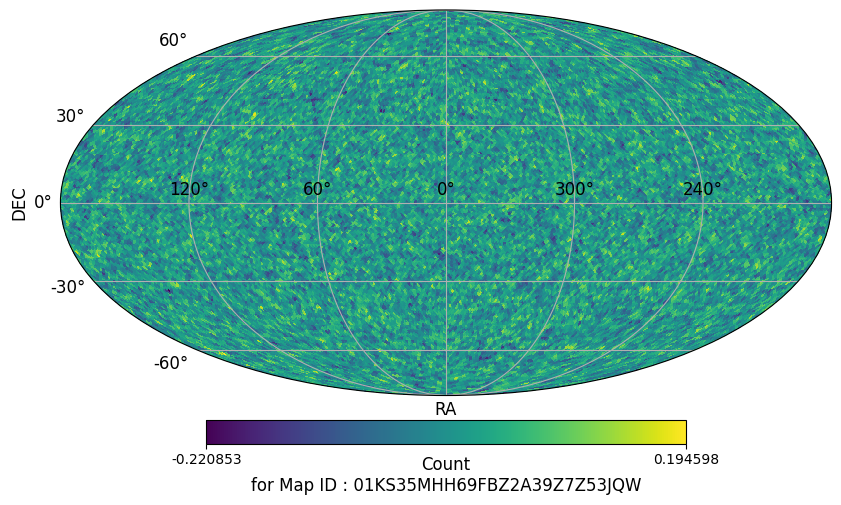

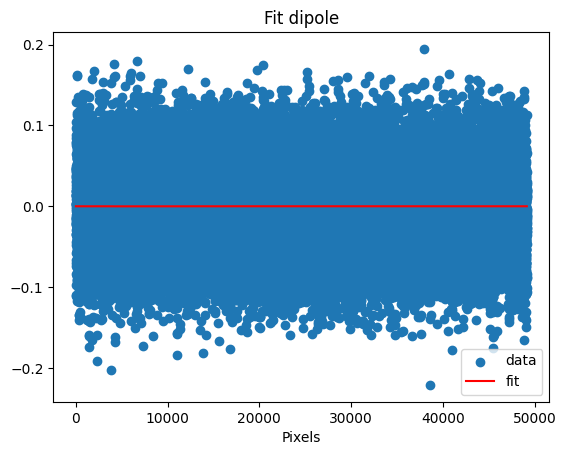

In [3]:
DIR = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR + sufix + '.fits'

clMapper = CountMapper.read_map_fits(clFile, idx=3, nest=False) #first clustering map
clMapper = clMapper.invert_nest()

generator = Generator(nside = clMapper.nside, nest = clMapper.nest)

init =  (0, 100, 0)
clMapper.fit_dipole("", init, fit_monop=False)

## Dipole creation

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.519e-05 (χ²/ndof = 0.0)  │              Nfcn = 327              │
│ EDM = 6.51e-05 (Goal: 0.0002)    │            time = 5.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  1.0e-3   │  0.2e-3   │  -0.2e-3   │   0.2e-3   │    0    │    1    │       │
│ 1 │ ra   │   168.0   │    2.3    │    -2.3    │    2.3     │    0    │   360   │       │
│ 2 │ dec  │    -7     │     4     │     -4     │     4      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.2e-3  │  0.2e-3   │   -2.3    │    2.3    │    -4     │     4     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       ra      dec │
├─────┼────────────────────────────┤
│   A │ 4.07e-08 -0.57e-6  1.79e-6 │
│  ra │ -0.57e-6     5.08       -3 │
│ dec │  1.79e-6       -3     13.3 │
└─────┴────────────────────────────┘

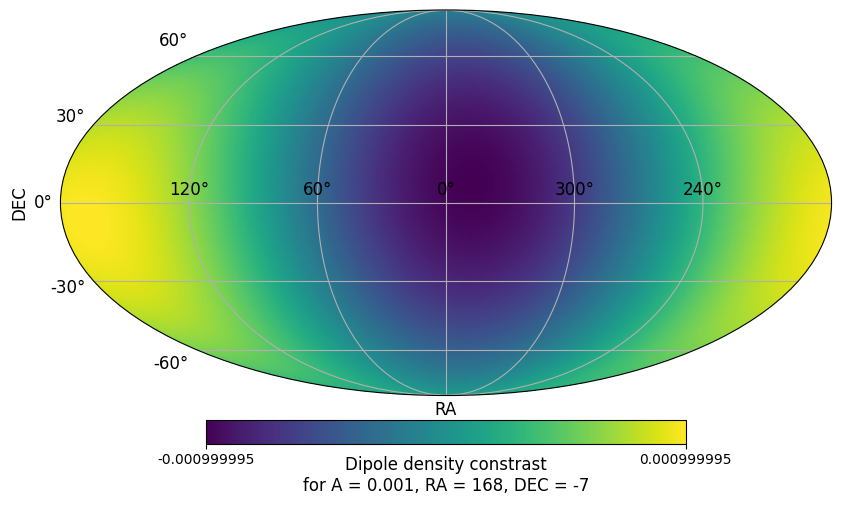

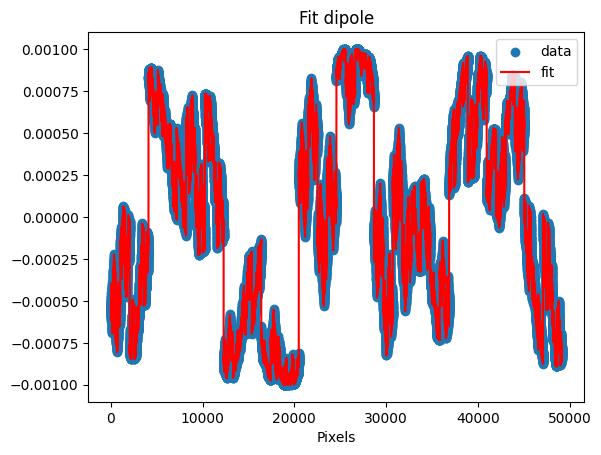

In [4]:
A, ra, dec = 0.001, 168, -7
dipoleMapper = generator.generate_dipoleContrast(A, ra, dec)

init =  (1, 100, 0)
dipoleMapper.fit_dipole("", init, fit_monop=False)

## Dipole + clustering

### Model comparison

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1872 (χ²/ndof = 0.0)       │              Nfcn = 606              │
│ EDM = 6.54e-05 (Goal: 0.0002)    │            time = 9.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.6e-6   │ 7396.4e-6 │  -0.6e-6   │ 7396.4e-6  │    0    │    1    │       │
│ 1 │ ra   │    80     │    180    │    -80     │    280     │    0    │   360   │       │
│ 2 │ dec  │    10     │    140    │    -100    │     80     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.6e-6  │ 7396.4e-6 │    -80    │    280    │   -100    │    80     │
│  Valid   │   True    │   False   │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │           A          ra         dec │
├─────┼─────────────────────────────────────┤
│   A │    1.63e-08 1.904881e-3 -317.969e-6 │
│  ra │ 1.904881e-3    9.36e+04          -0 │
│ dec │ -317.969e-6          -0     3.2e+04 │
└─────┴─────────────────────────────────────┘

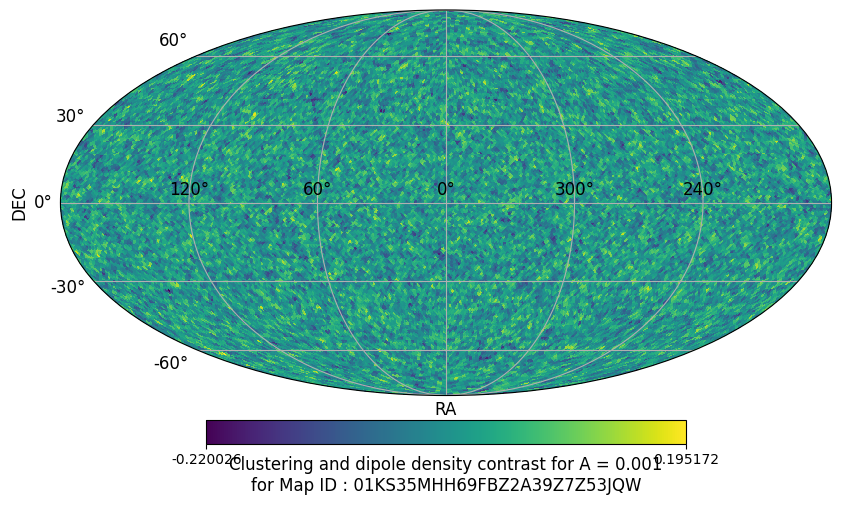

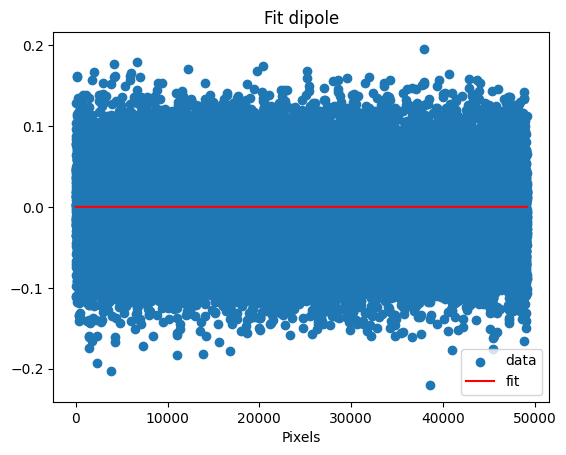

In [5]:
dipoleClMapper = generator.generate_dipoleContrast(A, ra, dec, clMapper=clMapper, unit = f"Clustering and dipole density contrast for A = {A}")
init =  (1, 100, 0)
dipoleClMapper.fit_dipole("", init, fit_monop=False)

Unable to use minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.125e+08 (χ²/ndof = 2288.5)│              Nfcn = 216              │
│ EDM = 0.00342 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.780e3 │  0.005e3  │            │            │    0    │         │       │
│ 1 │ A    │  913e-6   │   8e-6    │            │            │    0    │    1    │       │
│ 2 │ ra   │   209.9   │    0.5    │            │            │    0    │   360   │       │
│ 3 │ dec  │   -26.6   │    0.5    │            │            │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │      20.3   0.86e-9      -0.0     -0.00 │
│   A │   0.86e-9  6.13e-11 -93.15e-9 -84.60e-9 │
│  ra │      -0.0 -93.15e-9     0.301     -0.00 │
│ dec │     -0.00 -84.60e-9     -0.00     0.241 │
└─────┴─────────────────────────────────────────┘

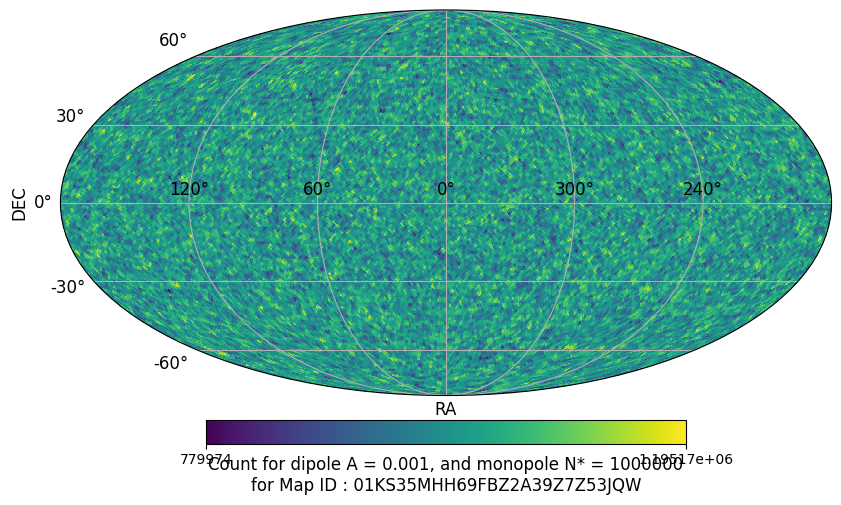

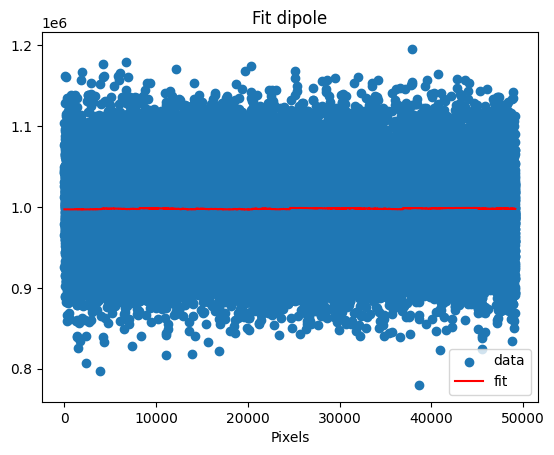

In [6]:
monopMapper = generator.generate_monopole(NSource_px_th, contrastMapper=dipoleClMapper, unit = f"Count for dipole A = {A}, and monopole N* = {NSource_px_th}")

init =  (1e6, 1, 100, 0)
monopMapper.fit_dipole("", init)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.125e+08 (χ²/ndof = 2288.5)│              Nfcn = 857              │
│ EDM = 2.01e-05 (Goal: 0.0002)    │           time = 18.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name       │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*         │ 997.780e3 │  0.005e3  │  -0.005e3  │  0.005e3   │    0    │         │       │
│ 1 │ A          │ 0.272e-3  │ 0.017e-3  │ -0.017e-3  │  0.017e-3  │    0    │    1    │       │
│ 2 │ ra         │   209.9   │    0.5    │    -0.5    │    0.5     │    0    │   360   │       │
│ 3 │ dec        │   -26.6   │    0.5    │    -0.5    │    0.5     │   -90   │   90    │       │
│ 4 │ cos(alpha) │   0.911   │   0.024   │   -0.024   │   0.024    │   -1    │    1    │       │
└───┴────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │      cos(alpha)       │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     5     │ -0.017e-3 │ 0.017e-3  │   -0.5    │    0.5    │   -0.5    │    0.5    │  -0.024   │   0.024   │
│  Valid   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────────────┬────────────────────────────────────────────────────────┐
│            │         N*          A         ra        dec cos(alpha) │
├────────────┼────────────────────────────────────────────────────────┤
│         N* │       20.3   -3.05e-9       -0.0      -0.00          0 │
│          A │   -3.05e-9   2.96e-10 -130.78e-9 -118.87e-9 -371.72e-9 │
│         ra │       -0.0 -130.78e-9      0.301      -0.00     0.1e-3 │
│        dec │      -0.00 -118.87e-9      -0.00      0.241          0 │
│ cos(alpha) │          0 -371.72e-9     0.1e-3          0   0.000589 │
└────────────┴────────────────────────────────────────────────────────┘

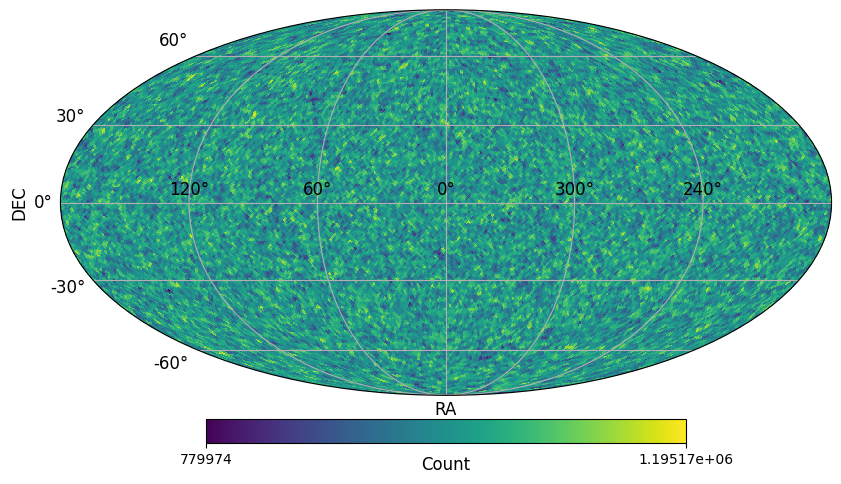

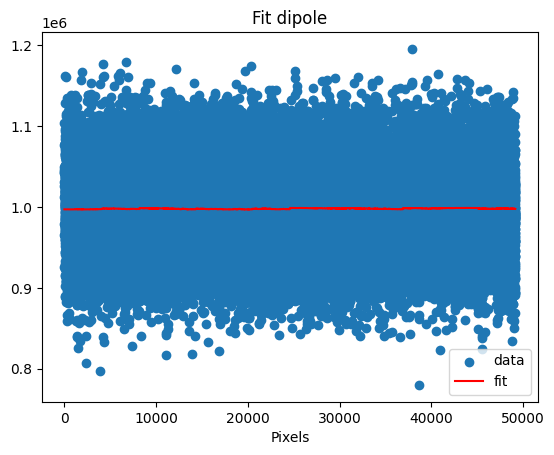

In [8]:
##### Clustering density count map: #####
class ClusteringCountMapper(CountMapper):
    """A class to read and manipulate density maps with clustering dipole."""
    _settingsFit_MD = {"bounds": ([0, 0, 0, -90, -1], [np.inf, 1, 360, 90, 1]), #default settings to use in self.fit_dipole()
        "names": ("N*", "A", "ra", "dec", "cos(alpha)")}
    _settingsFit_D = {"bounds": ([0, 0, -90, -1], [1, 360, 90, 1]), #default settings to use in self.fit_dipole()
        "names": ("A", "ra", "dec", "cos(alpha)")}
    _settingsFit = {"MD": _settingsFit_MD, "D": _settingsFit_D}
    
    def __init__(self, data, nside: int, nest: bool = True, hpmap=None, get_grouped=False, AclMean=7.04e-4):
        super().__init__(data=data, nside=nside, nest=nest, hpmap=hpmap, get_grouped=get_grouped)
        self.AclMean = AclMean #mean value of culstering amplitude
        #to create new default settings to use in self.fit_dipole(), specific to the instance.
        self._instance_settingsFit_MD = {"model": lambda hpmap, M, A, ra, dec, alpha, contrast : apply_dipole_MD(hpmap, M, A + self.AclMean*alpha, ra, dec, nest=self.nest, frame='icrs', contrast=contrast, cut_masked=True)}
        self._instance_settingsFit_D = {"model": lambda hpmap, A, ra, dec, alpha, contrast : apply_dipole_ARaDec(hpmap, A + self.AclMean*alpha, ra, dec, nest=self.nest, cut_masked=True)}
        self._instance_settingsFit = {"MD": self._instance_settingsFit_MD, "D": self._instance_settingsFit_D}


monopMapperCorr = ClusteringCountMapper.from_map(monopMapper.map)

init =  (1e6, 1, 100, 0, 0)
bounds = ([0, 0, 0, -90, -1], [np.inf, 1, 360, 90, 1])
monopMapperCorr.fit_dipole("", init, bounds=bounds)

In [9]:
10.545e-3 - 7.04e-4

0.009841

In [10]:
10.31e-3 - 5*0.05e-3

0.01006